# Session -8 Regression algorithms part 3

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Task 1.
Use sklearn's PolynomialFeatures() to transform a dataset of mobile phone prices (features: RAM, storage) into polynomial features up to degree 2, and print the resulting feature matrix.

In [14]:
df = pd.read_csv(r"C:\Users\DHRUV MODI\Documents\TOPS\Data set\Mobile phone price.csv")
df.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799


In [15]:
df.columns = df.columns.str.strip()

In [16]:
df['RAM'] = pd.to_numeric(df['RAM'].astype(str).str.replace(r'[^\d]', '', regex=True), errors='coerce')
df['Storage'] = pd.to_numeric(df['Storage'].astype(str).str.replace(r'[^\d]', '', regex=True), errors='coerce')
df = df.dropna()

In [17]:
X = df[['RAM', 'Storage']]

In [18]:
from sklearn.preprocessing import PolynomialFeatures

In [19]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [20]:
print("Feature Names:", poly.get_feature_names_out(['RAM', 'Storage']).tolist())
print(X_poly)

Feature Names: ['RAM', 'Storage', 'RAM^2', 'RAM Storage', 'Storage^2']
[[6.0000e+00 1.2800e+02 3.6000e+01 7.6800e+02 1.6384e+04]
 [1.2000e+01 2.5600e+02 1.4400e+02 3.0720e+03 6.5536e+04]
 [8.0000e+00 1.2800e+02 6.4000e+01 1.0240e+03 1.6384e+04]
 ...
 [6.0000e+00 1.2800e+02 3.6000e+01 7.6800e+02 1.6384e+04]
 [8.0000e+00 1.2800e+02 6.4000e+01 1.0240e+03 1.6384e+04]
 [6.0000e+00 1.2800e+02 3.6000e+01 7.6800e+02 1.6384e+04]]


# Task 2.
Train both a LinearRegression and a Polynomial Regression (degree=3) model on a dataset of Zomato restaurant ratings versus number of reviews, then plot both predictions on the same chart to compare their fits.<br><br><em><strong>Hint:</strong> Use matplotlib for plotting and clearly label both curves.</em>

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [22]:
df = pd.read_csv(r"C:\Users\DHRUV MODI\Documents\TOPS\Data set\zomato restaurant.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,0,0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,1,1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,2,2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,3,3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,4,4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


In [23]:
df.dropna(inplace=True)

In [30]:
X = df[['num of ratings']].values
y = df['rate (out of 5)'].values

In [32]:
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

In [33]:
linear_model = LinearRegression()
linear_model.fit(X_sorted, y_sorted)
linear_preds = linear_model.predict(X_sorted)

In [34]:
poly_feat = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_feat.fit_transform(X_sorted)

In [35]:
poly_model = LinearRegression()
poly_model.fit(X_poly, y_sorted)
poly_preds = poly_model.predict(X_poly)

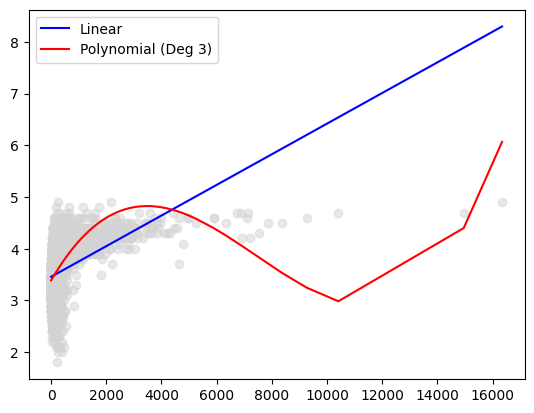

In [36]:
plt.scatter(X_sorted, y_sorted, color='lightgray', alpha=0.5)
plt.plot(X_sorted, linear_preds, color='blue', label='Linear')
plt.plot(X_sorted, poly_preds, color='red', label='Polynomial (Deg 3)')
plt.legend()
plt.show()

# Task 3.
Given a dataset where the relationship between followers and posts for Instagram users is non-linear, fit a polynomial regression model (degree=4) and check for overfitting by plotting the training and validation errors for degrees 1 to 5.

In [42]:
np.random.seed(42)
posts = np.random.uniform(10, 500, 100).reshape(-1, 1)
followers = 5000 + 15 * (posts**1.8) + np.random.normal(0, 100000, 100).reshape(-1, 1)

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_val, y_train, y_val = train_test_split(
    posts, followers, test_size=0.3, random_state=42
)

In [45]:
train_errors, val_errors = [], []
degrees = [1, 2, 3, 4, 5]

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [49]:
for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.fit_transform(X_val)

    model = LinearRegression().fit(X_train_poly, y_train)

    train_errors.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    val_errors.append(mean_squared_error(y_val, model.predict(X_val_poly)))

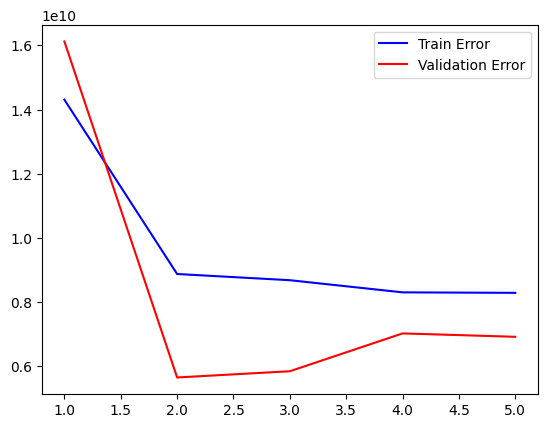

In [50]:
plt.plot(degrees, train_errors, label="Train Error", color="blue")
plt.plot(degrees, val_errors, label="Validation Error", color="red")
plt.legend()
plt.show()

# Task 4.
Add L2 regularization (Ridge regression) to your polynomial regression model (degree=3) on a Flipkart product price prediction dataset, and compare the model's performance with and without regularization.<br><br><em><strong>Hint:</strong> Use Ridge from sklearn.linear_model and explain any difference in test error.</em>

In [55]:
df = pd.read_csv(r"C:\Users\DHRUV MODI\Documents\TOPS\Data set\flipkart_product.csv\flipkart_product.csv",encoding='Latin1')
df.head()

,ProductName,Price,Rate,Review,Summary
0,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",5,Super!,Great cooler.. excellent air flow and for this...
1,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",5,Awesome,Best budget 2 fit cooler. Nice cooling
2,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",3,Fair,The quality is good but the power of air is de...
3,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",1,Useless product,Very bad product it's a only a fan
4,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",3,Fair,Ok ok product


In [57]:
df["Price"] = pd.to_numeric(df["Price"].str.replace(r"[^\d]", "", regex=True), errors="coerce")

In [58]:
df["Rate"] = pd.to_numeric(df["Rate"], errors="coerce")
df = df.dropna(subset=["Price", "Rate"])

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["Rate"]], df["Price"], test_size=0.2, random_state=42
)

In [60]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

In [ ]:
model_standard = LinearRegression().fit(X_train_poly, y_train)
print("Standard Test MSE:", mean_squared_error(y_test, model_standard.predict(X_test_poly)))

Standard Test MSE: 103767424.11409518


In [63]:
from sklearn.linear_model import Ridge

In [64]:
model_ridge = Ridge(alpha=1.0).fit(X_train_poly, y_train)
print("Ridge Test MSE:", mean_squared_error(y_test, model_ridge.predict(X_test_poly)))

Ridge Test MSE: 103767429.20052995


# Task 5.
Use ChatGPT or Copilot to generate Python code that demonstrates underfitting and overfitting using polynomial regression on a synthetic dataset, then run the code and explain in your own words how model degree affects bias and variance.

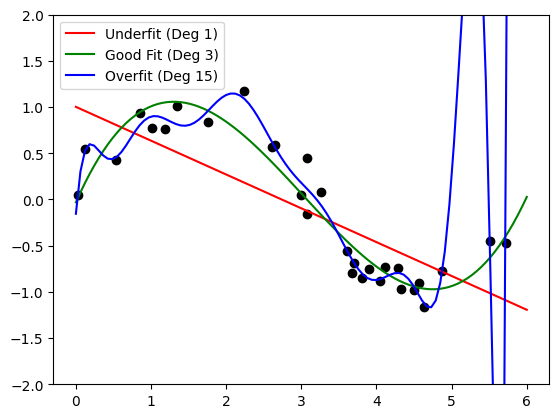

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(10)
X = np.sort(np.random.rand(30, 1) * 6, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])
X_plot = np.linspace(0, 6, 100).reshape(-1, 1)

plt.scatter(X, y, color="black")

for degree, color, label in zip(
    [1, 3, 15],
    ["red", "green", "blue"],
    ["Underfit (Deg 1)", "Good Fit (Deg 3)", "Overfit (Deg 15)"],
):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    model = LinearRegression().fit(poly.fit_transform(X), y)
    plt.plot(X_plot, model.predict(poly.transform(X_plot)), color=color, label=label)

plt.ylim(-2, 2)
plt.legend()
plt.show()